In [1]:
import requests
import pandas as pd
import time
from collections import defaultdict
import concurrent
from concurrent.futures import ThreadPoolExecutor
from urllib.parse import urlparse, parse_qs
from tqdm import tqdm  # Importing tqdm for the progress bar
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import seaborn as sb
import statsmodels.api as sm
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
%load_ext rpy2.ipython

In [ ]:
#Read in National Dictionary and HDI Reference
country_df_dict = pd.read_csv('affiliation_dictionary.csv')
hdi_countries = pd.read_csv('backbone_anesthesiology.csv')
hdi_countries_merge = hdi_countries.merge(country_df_dict, on = 'country', how = 'outer')

In [ ]:
#Total Article Count from 1920 - 2022
api_key = 'eb2cec89a26c7449245d9379a4f9944e'
#api_key = '41e72f874714fb6cdc138372a347c03b'
base_url = 'https://api.elsevier.com/content/search/scopus'
headers = {'Accept': 'application/json'}

for i in range(len(hdi_countries_merge)):
    query = f'TITLE-ABS-KEY("anesthes*" OR "anaesthes*") AND AFFILCOUNTRY({hdi_countries_merge.loc[i, "country"]})'
    params = {
        'query': query,
        'count': 25,  # Max number of results per page
        'date': '1920-2022',
        'apiKey': api_key
    }
    response = requests.get(base_url, headers=headers, params=params)
    if response.status_code == 200:
        data = response.json()
        total = data.get('search-results').get('opensearch:totalResults')
        hdi_countries_merge.loc[i, 'anesthesiology'] = total

In [ ]:
#Total Article Count Per Year from 1920 - 2022
api_key = 'eb2cec89a26c7449245d9379a4f9944e'
base_url = 'https://api.elsevier.com/content/search/scopus'
headers = {'Accept': 'application/json'}

# Define a function to fetch data for each country and year
def fetch_data(i, year):
    country = hdi_countries_merge.loc[i, 'country']
    if pd.isnull(country):  # Skip if country is missing
        return

    query = f'TITLE-ABS-KEY("anesthes*" OR "anaesthes*") AND AFFILCOUNTRY({country})'
    params = {
        'query': query,
        'count': 25,
        'date': year,
        'apiKey': api_key
    }

    response = requests.get(base_url, headers=headers, params=params)
    if response.status_code == 200:
        data = response.json()
        try:
            total = data.get('search-results', {}).get('opensearch:totalResults', 0)
            hdi_countries_merge.loc[i, f'{year}'] = total
        except KeyError:
            print(f"Error in response structure for {country} and year {year}")
    else:
        print(f"Failed to fetch data for {country} and year {year}")

# Using ThreadPoolExecutor for concurrent requests
with ThreadPoolExecutor(max_workers=10) as executor:
    # Wrap the outer loop (countries) with tqdm for progress tracking
    for i in tqdm(range(len(hdi_countries_merge)), desc="Processing countries", unit="country"):
        # Wrap the inner loop (years) with tqdm
        for year in range(1920, 2022):
            executor.submit(fetch_data, i, year)
            time.sleep(1)  # Optional: to prevent hitting rate limits

In [ ]:
hdi_countries_merge.to_csv('merged_article_counts_by_country_across_years.csv', index=False)

In [ ]:
#Adjudication of results from above. Script written for Egypt.
api_key = 'eb2cec89a26c7449245d9379a4f9944e'
base_url = 'https://api.elsevier.com/content/search/scopus'
headers = {'Accept': 'application/json'}
query = 'TITLE-ABS-KEY("anesthes*" OR "anaesthes*") AND AFFILCOUNTRY("Sierra Leone")'
params = {
    'query': query,
    'count': 25,  # Max number of results per page
    'date': '1920-2022',
    'apiKey': api_key
}

# List to hold all the entries
all_entries = []

# Initial request
page_number = 1
while True:
    # Make the GET request
    response = requests.get(base_url, headers=headers, params=params)
    
    # Check if the response is successful
    if response.status_code == 200:
        data = response.json()
        total = data.get('search-results', {})
        entries = total.get('entry', [])
        
        # Add a tqdm progress bar for the processing of the current page's entries
        for entry in tqdm(entries, desc=f"Processing Page {page_number}", leave=False):
            title = entry.get('dc:title', "No Title")
            authors = entry.get('dc:creator', "No Author")
            publication_name = entry.get('prism:publicationName', "No Publication Name")
            publication_date = entry.get('prism:coverDate', "No Date")
            
            # Append the details to the list
            all_entries.append({
                "title": title,
                "authors": authors,
                "publication_name": publication_name,
                "publication_date": publication_date
            })
        
        # Check if there is a 'next' link for pagination
        links = total.get('link', [])
        next_link = None
        for link in links:
            if link.get('@ref') == 'next':
                next_link = link.get('@href')
                break
        
        # If there is a 'next' link, update the params for the next page
        if next_link:
            # Update params with the next page URL
            parsed_url = urlparse(next_link)
            params['start'] = parse_qs(parsed_url.query).get('start', [None])[0]
            page_number += 1  # Increment the page number for the progress bar
        else:
            # No more pages, exit the loop
            break
    else:
        # Handle the case where the request fails
        print(f"Error: {response.status_code}")
        break

# Convert the list of entries into a pandas DataFrame
df = pd.DataFrame(all_entries)

# Output the collected DataFrame
print(f"Collected {len(df)} entries.")
print(df.head())  # Print the first few rows to check the results
df.to_csv('script_adjudication_sierra_leone.csv')

In [2]:
#Creating World Dataset from Total Article Counts
##Note Total Article Count dataset requires manual refinement
##given duplicate country names. Refinement should be completed
##prior to merging with Geopandas dataset. Countries excluded
##from refinement include Czechoslovakia, Yugoslavia, Macao, 
##Gibraltar, Reunion, Northern Mariana Islands, and No Country
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
data_input = pd.read_csv('merged_article_counts_by_country_across_years.csv')
oecd = pd.read_csv('oecd_iso3_codes.csv')
world = world.merge(data_input, left_on='ADM0_A3', right_on='iso3', how='left')
world['log'] = np.log10(world['anesthesiology'].abs()+1)

In [ ]:
#Atlas Generation on World Dataset
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5,)  # Plot the boundaries of countries
plot = world.plot(column='log', ax=ax, legend=True,
           legend_kwds={'label': "Log10 Normalized National Publication Volume",
                        'orientation': "horizontal"},
           cmap='Blues').set_axis_off()  # You can change the color map (e.g., 'Oranges', 'Blues', 'YlGnBu')
#plt.savefig("National Publication Density.pdf", format="pdf")
plt.show()

In [ ]:
#Analysis on World dataset
sb.set(style = 'white')
desired_order = ['Very High', 'High', 'Medium', 'Low']
sb.violinplot(x ="hdicode", y = np.log10(data_input['anesthesiology'].abs()+1), 
              order = desired_order, palette = "PuBu_r",
              data = data_input)
#plt.savefig("HDI Distribution.pdf", format="pdf")

In [ ]:
#Bland-Altman Plot
f, ax = plt.subplots(1, figsize = (8,5))
sm.graphics.mean_diff_plot(np.log10(data_input['anesthesiology'].abs()+1), np.log10(data_input['total_yearly'].abs()+1), ax = ax)
ax.set_ylim(-1, 1)
#plt.savefig("Bland-Altman.pdf", format="pdf")
plt.show()

In [3]:
#Statistical Analyses
print(data_input['hdicode'].value_counts())

hdi_very_high = data_input.loc[data_input["hdicode"]=="Very High", ]
hdi_high = data_input.loc[data_input["hdicode"]=="High", ]
hdi_medium = data_input.loc[data_input["hdicode"]=="Medium", ]
hdi_low = data_input.loc[data_input["hdicode"]=="Low", ]
top_performers = data_input.sort_values(by='anesthesiology', ascending=False).head(10)
oecd_performers = oecd.merge(data_input, left_on='ISO3', right_on='iso3', how='left').drop(['Country','ISO3'], axis=1)

stat, p_value = kruskal(np.log10(hdi_very_high['anesthesiology'].abs()+1),
                        np.log10(hdi_high['anesthesiology'].abs()+1),
                        np.log10(hdi_medium['anesthesiology'].abs()+1),
                        np.log10(hdi_low['anesthesiology'].abs()+1))

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p_value)

hdicode
Very High    71
High         49
Medium       42
Low          33
Name: count, dtype: int64
Kruskal-Wallis statistic: 51.980262722607776
p-value: 3.024230584080606e-11


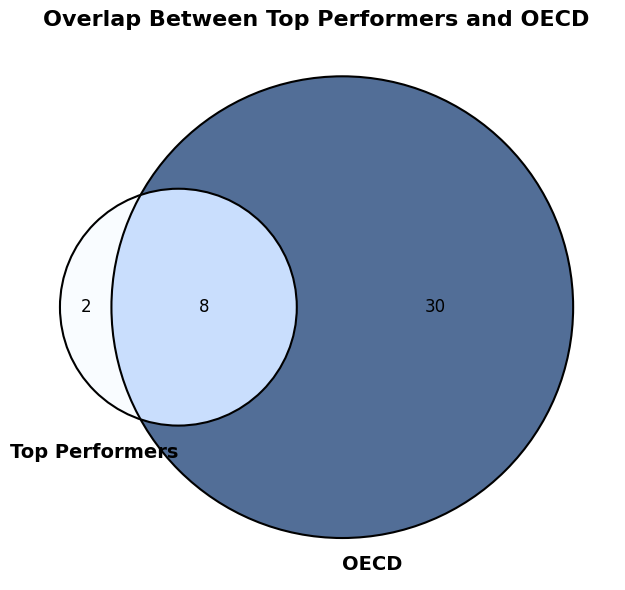

   Only in Top Performers Overlap Only in OECD
0                     CHN     CAN          AUS
1                     IND     DEU          AUT
2                     NaN     FRA          BEL
3                     NaN     GBR          CHE
4                     NaN     ITA          CHL
5                     NaN     JPN          COL
6                     NaN     TUR          CRI
7                     NaN     USA          CZE
8                     NaN     NaN          DNK
9                     NaN     NaN          ESP
10                    NaN     NaN          EST
11                    NaN     NaN          FIN
12                    NaN     NaN          GRC
13                    NaN     NaN          HUN
14                    NaN     NaN          IRL
15                    NaN     NaN          ISL
16                    NaN     NaN          ISR
17                    NaN     NaN          KOR
18                    NaN     NaN          LTU
19                    NaN     NaN          LUX
20           

In [4]:
#Venn Diagram of Top Performers and OECD
# Extract sets from the 'Name' column
set1 = set(top_performers['iso3'])
set2 = set(oecd_performers['iso3'])

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))
venn = venn2([set1, set2], set_labels=('Top Performers', 'OECD'), ax=ax, set_colors=('#f7fbff', '#08306b'), alpha=0.7)

# Add circle styling
venn2_circles([set1, set2], linestyle='solid', linewidth=1.5, color='black')

# Custom label styling
for text in venn.set_labels:
    text.set_fontsize(14)
    text.set_fontweight('bold')

for text in venn.subset_labels:
    if text:
        text.set_fontsize(12)

# Add title with custom font
plt.title('Overlap Between Top Performers and OECD', fontsize=16, fontweight='bold')

# Remove spines and ticks for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Save if needed
#plt.savefig("Venn.pdf", format="pdf")

#Display
plt.tight_layout()
plt.show()
only_top = sorted(set1 - set2)
only_oecd = sorted(set2 - set1)
overlap = sorted(set1 & set2)

# Create table DataFrame
venn_table = pd.DataFrame({
    'Only in Top Performers': pd.Series(only_top),
    'Overlap': pd.Series(overlap),
    'Only in OECD': pd.Series(only_oecd)
})

print(venn_table)

In [ ]:
#Scatterplot
sb.scatterplot(data=data_input, x=np.log10(data_input['anesthesiology'].abs()+1), y=np.log10(data_input['total_yearly'].abs()+1))
corr_coef, p_value = pearsonr(np.log10(data_input['anesthesiology'].abs()+1), np.log10(data_input['total_yearly'].abs()+1))
m, b = np.polyfit(np.log10(data_input['anesthesiology'].abs()+1), np.log10(data_input['total_yearly'].abs()+1), 1)  # 1 is the degree of the polynomial (line)
plt.plot(np.log10(data_input['anesthesiology'].abs()+1), m*np.array(np.log10(data_input['anesthesiology'].abs()+1)) + b, color='black')
plt.title(f'Scatter plot\nCorrelation: {corr_coef:.2f}, p-value: {p_value:.3f}')
#plt.savefig("Scatterplot.pdf", format="pdf")
plt.show()

In [ ]:
#Time Trend for Total Article Counts
start_year = '1920'
end_year = '2021'

# Select a range of columns (inclusive of start and end year)
df_range = data_input.loc[:, start_year:end_year]
column_sums = df_range.sum(axis=0)
plt.figure(figsize=(10, 6))
plt.plot(column_sums.index, column_sums.values, color='navy', label='Sum of Values')

# Shade the area under the curve
plt.fill_between(column_sums.index, column_sums.values, color='steelblue', alpha=0.4)

# Adding labels and title
plt.title('Sum of Columns over Time')
plt.xlabel('Year')
plt.ylabel('Sum of Values')
plt.grid(False)

# Customizing the x-axis: Display only every 10th year
# Generate a list of every 10th year (e.g., from 2000, 2010, etc.)
xticks = [year for i, year in enumerate(column_sums.index) if i % 10 == 0]

# Set the x-axis ticks and labels
plt.xticks(xticks)

# Show the plot
#plt.savefig("Time Series.pdf", format="pdf")
plt.show()

In [ ]:
#Time Trend for Total Article Counts by HDI
start_year = '1960'
end_year = '2021'
plt.figure(figsize=(10, 6))

hdi_codes = ['Very High', 'High', 'Medium', 'Low']

# Get a color palette from the "PuBu_r" colormap (reverse version of the "PuBu" palette)
colors = plt.cm.jet(np.linspace(0, 1, len(hdi_codes)))

# Select a range of columns (inclusive of start and end year)
for i, code in enumerate(hdi_codes):
    df_range = data_input.loc[data_input["hdicode"]==code, start_year:end_year]
    column_sums = df_range.sum(axis=0)
    plt.plot(column_sums.index, column_sums.values, label=code, color=colors[i])
    plt.fill_between(column_sums.index, column_sums.values, color=colors[i], alpha=0.4)
    
# Adding labels and title
plt.title('Sum of Columns over Time')
plt.xlabel('Year')
plt.ylabel('Sum of Values')
plt.grid(False)

# Customizing the x-axis: Display only every 10th year
# Generate a list of every 10th year (e.g., from 2000, 2010, etc.)
xticks = [year for i, year in enumerate(column_sums.index) if i % 10 == 0]

# Set the x-axis ticks and labels
plt.xticks(xticks)

# Add a legend to distinguish the lines by HDI code
plt.legend(title='HDI Code')

# Show the plot
#plt.savefig("Time Series by HDI Code.pdf", format="pdf")
plt.show()

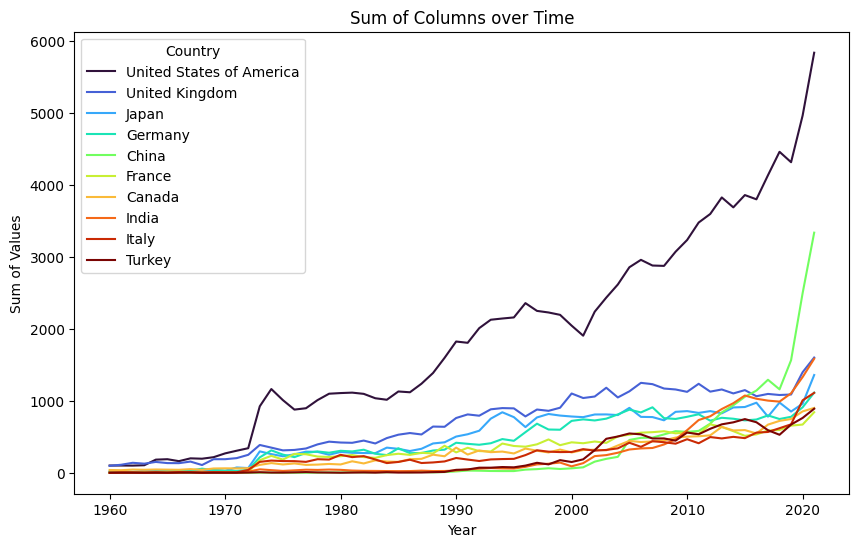

In [10]:
#Time Trend for Total Article Counts in Top Performers
start_year = '1960'
end_year = '2021'
plt.figure(figsize=(10, 6))

# Select a range of columns (inclusive of start and end year)
nations = top_performers["country"]

# Get a color palette from the "PuBu_r" colormap (reverse version of the "PuBu" palette)
colors = plt.cm.turbo(np.linspace(0, 1, len(top_performers['country'])))

for i, nation in enumerate(nations):
    df_range = top_performers.loc[top_performers["country"]==nation, start_year:end_year]
    column_sums = df_range.sum(axis=0)
    plt.plot(column_sums.index, column_sums.values, label=nation, color=colors[i])
    #plt.fill_between(column_sums.index, column_sums.values, color=colors[i], alpha=0.4)
    
# Adding labels and title
plt.title('Sum of Columns over Time')
plt.xlabel('Year')
plt.ylabel('Sum of Values')
plt.grid(False)

# Customizing the x-axis: Display only every 10th year
# Generate a list of every 10th year (e.g., from 2000, 2010, etc.)
xticks = [year for i, year in enumerate(column_sums.index) if i % 10 == 0]

# Set the x-axis ticks and labels
plt.xticks(xticks)

# Add a legend to distinguish the lines by HDI code
plt.legend(title='Country')

# Show the plot
#plt.savefig("Time Series by Country (Top Performers).pdf", format="pdf")
plt.show()

In [ ]:
#Long format transformtation for all article counts
data_input_clean = data_input.drop(['hdicode','anesthesiology','total_yearly'], axis=1)
data_input_clean_long = pd.melt(data_input_clean, id_vars=['country','hdi_2022','iso3'], var_name='year', value_name='count')
data_input_clean_long['year'] = data_input_clean_long['year'].astype(int)
data_input_final = data_input_clean_long[data_input_clean_long['year']>=1960].reset_index(drop=True)

In [5]:
#Long format transformtation for top performer article counts
top_performers_clean = top_performers.drop(['hdicode','anesthesiology','total_yearly','hdi_2022'], axis=1)
top_performers_clean_long = pd.melt(top_performers_clean, id_vars=['country','iso3'], var_name='year', value_name='count')
top_performers_clean_long['year'] = top_performers_clean_long['year'].astype(int)
top_performers_final = top_performers_clean_long[top_performers_clean_long['year']>=1960].reset_index(drop=True)

In [6]:
#Long format transformtation for OECD article counts
oecd_clean = oecd_performers.drop(['hdicode','anesthesiology','total_yearly','hdi_2022'], axis=1)
oecd_clean_long = pd.melt(oecd_clean, id_vars=['country','iso3'], var_name='year', value_name='count')
oecd_clean_long['year'] = oecd_clean_long['year'].astype(int)
oecd_final = oecd_clean_long[oecd_clean_long['year']>=1995].reset_index(drop=True)

In [7]:
#Long format transformtation of World Bank indicators
world_bank = pd.read_csv('world_bank.csv')
world_bank_long = world_bank.melt(id_vars=['Series Code','Country Name','Country Code'], var_name='year', value_name='count')
world_bank_long = world_bank_long.drop('Country Name', axis=1)
world_bank_long['year'] = pd.to_numeric(world_bank_long['year'])
world_bank_long_pivot = world_bank_long.pivot_table(
    index=['Country Code', 'year'],
    columns='Series Code',
    values='count',
    aggfunc='sum'  # or 'mean', etc., depending on your use case
).reset_index()
world_bank_long_pivot = world_bank_long_pivot.rename(columns={'Country Code': 'iso3'})
world_bank_long_pivot = world_bank_long_pivot.drop('GB.XPD.RSDV.GD.ZS', axis=1)

In [8]:
#Merging Top Performer Article Counts with World Bank Indicators
pvar_dataset_top = top_performers_final.merge(world_bank_long_pivot, on = ['iso3','year'], how = 'left')
pvar_dataset_top['country'] = pvar_dataset_top['country'].astype(str)      # or .astype('category') if you like
pvar_dataset_top['year'] = pvar_dataset_top['year'].astype(int)          # or float, but must be numeric
for col in ['count', 'NY.GDP.MKTP.CD','NY.GDP.PCAP.CD']:
    pvar_dataset_top[col] = pd.to_numeric(pvar_dataset_top[col], errors='coerce')
pvar_dataset_nona = pvar_dataset_top.dropna()

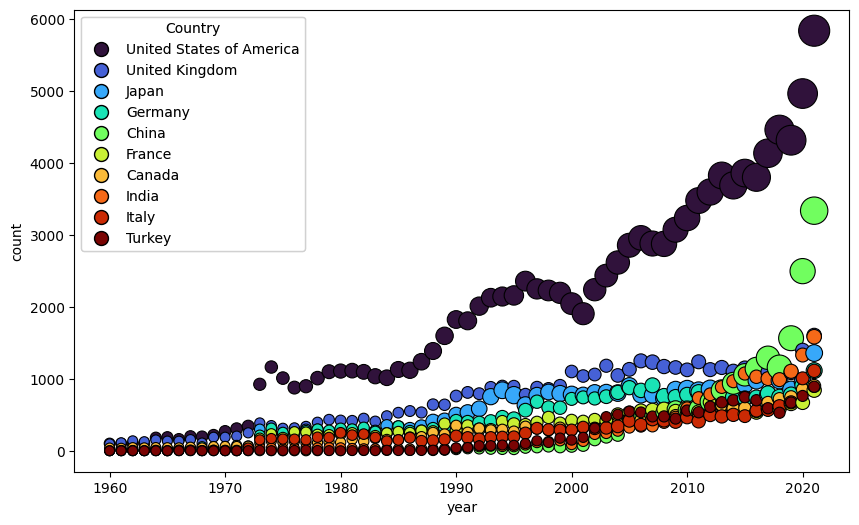

In [64]:
plt.figure(figsize=(10, 6))
scatter = sb.scatterplot(
    data=pvar_dataset_nona,
    x='year',
    y='count',
    hue='country',
    size='NY.GDP.MKTP.CD',
    sizes=(50, 500),
    palette=colors.tolist(),
    edgecolor='black',
    linewidth=0.8,
    legend=False
)

color_handles = [
    Line2D([0], [0], marker='o', color='w', label=country,
           markerfacecolor=color, markersize=10, markeredgecolor='black')
    for country, color in zip(pvar_dataset_nona['country'], sb.color_palette(colors.tolist()))
]

legend1 = plt.legend(handles=color_handles, title='Country', loc='upper left')
plt.gca().add_artist(legend1)
plt.savefig("Time Series by Country with GDP (Top Performers).pdf", format="pdf")
plt.show()

In [41]:
#Merging OECD Article Counts with World Bank Indicators
pvar_dataset_oecd = oecd_final.merge(world_bank_long_pivot, on = ['iso3','year'], how = 'left')
pvar_dataset_oecd['country'] = pvar_dataset_oecd['country'].astype(str)      # or .astype('category') if you like
pvar_dataset_oecd['year'] = pvar_dataset_oecd['year'].astype(int)          # or float, but must be numeric
for col in ['count', 'NY.GDP.MKTP.CD','NY.GDP.PCAP.CD']:
    pvar_dataset_oecd[col] = pd.to_numeric(pvar_dataset_oecd[col], errors='coerce')
pvar_dataset_oecd_nona = pvar_dataset_oecd.dropna()

In [58]:
#Sendng to R
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects import globalenv

pandas2ri.activate()
globalenv['df'] = pandas2ri.py2rpy(pvar_dataset_nona)
globalenv['oecd_df'] = pandas2ri.py2rpy(pvar_dataset_oecd_nona)

In [59]:
%%R
library(dplyr)
library(panelvar)

# ------------------------------
# 1. Force correct types
# ------------------------------
df$iso3 <- as.factor(df$iso3)
df$year <- as.numeric(df$year)
df <- df[, c("iso3", "year", "count", "NY.GDP.MKTP.CD")]
names(df) <- c("iso3", "year", "count", "gdp")
df <- na.omit(df)

# ------------------------------
# 2. Remove duplicates
# ------------------------------
df <- df %>% distinct(iso3, year, .keep_all = TRUE)

# ------------------------------
# 3. Check minimum years per country
# ------------------------------
country_year_counts <- df %>% group_by(iso3) %>% summarise(n_years = n())
print(country_year_counts)

# Optional: Drop countries with < 5 years of data
# (You can adjust the threshold if needed)
min_years_required <- 5
bad_countries <- country_year_counts %>% filter(n_years < min_years_required) %>% pull(iso3)

if (length(bad_countries) > 0) {
    cat("Dropping countries with too few years:", bad_countries, "\n")
    df <- df %>% filter(!iso3 %in% bad_countries)
}

# ------------------------------
# 4. Check for multicollinearity
# ------------------------------
cor_matrix <- cor(df %>% select(-iso3, -year), use = "pairwise.complete.obs")
print(round(cor_matrix, 2))

# Flagging correlations > 0.95
high_corr_pairs <- which(abs(cor_matrix) > 0.95 & abs(cor_matrix) != 1, arr.ind = TRUE)

if (length(high_corr_pairs) > 0) {
    cat("Warning: High multicollinearity detected among variables.\n")
    print(high_corr_pairs)
}

# ------------------------------
# 5. Final check: panel summary
# ------------------------------
cat("Panel dimensions after cleaning:\n")
print(dim(df))
cat("Countries:\n")
print(unique(df$iso3))
cat("Years span:\n")
print(range(df$year))

# Standardizing all variables except country and year
df <- df %>%
  mutate(across(-c(iso3, year), ~ scale(.) %>% as.numeric()))

# Convert to panel data
pvar_result <- pvarfeols(dependent_vars = c("count", "gdp"),
                         lags = 3,
                         transformation = "difference",
                         data = df,
                         panel_identifier = c("iso3", "year"))

summary(pvar_result)

# A tibble: 10 × 2
   iso3  n_years
   <fct>   <int>
 1 CAN        62
 2 CHN        62
 3 DEU        62
 4 FRA        62
 5 GBR        62
 6 IND        62
 7 ITA        62
 8 JPN        62
 9 TUR        62
10 USA        62
      count  gdp
count  1.00 0.93
gdp    0.93 1.00
Panel dimensions after cleaning:
[1] 620   4
Countries:
 [1] USA GBR JPN DEU CHN FRA CAN IND ITA TUR
Levels: CAN CHN DEU FRA GBR IND ITA JPN TUR USA
Years span:
[1] 1960 2021
---------------------------------------------------
Fixed Effects OLS Panel VAR estimation 
---------------------------------------------------
Transformation: difference 
Group variable: iso3 
Time variable: year 
Number of observations = 620 
Number of groups = 10 
Obs per group: min = 62 
               avg = 62 
               max = 62 

                     demeaned_count  demeaned_gdp
-------------------------------------------------
demeaned_lag1_count   1.2359 ***      0.2567 *** 
                     (0.0446)        (0.0216)    
demeane

In [ ]:
#Alternative method for pulling articles per year
#Not comprehensive as it relies on query of "anesthesiology" as opposed to "anesthes*"
# List of years to process
years = range(1920, 2022)
all_country_counts = defaultdict(lambda: defaultdict(int))  # {country: {year: count}}

# Process data for each year
for year in years:
    print(f"Processing data for {year}...")
    country_counts = collect_articles_per_country(year)
    
    # Store the counts for each country and year
    for country, count in country_counts.items():
        all_country_counts[country][year] = count

# Convert the dictionary to a pandas DataFrame
df = pd.DataFrame.from_dict(all_country_counts, orient='index')
df_sorted = df.sort_index(axis=1)
df_sorted.to_csv('article_counts_by_country.csv')

In [46]:
%%R
library(dplyr)

# ------------------------------
# 1. Force correct types
# ------------------------------
oecd_df$iso3 <- as.factor(oecd_df$iso3)
oecd_df$year <- as.numeric(oecd_df$year)
oecd_df <- oecd_df[, c("iso3", "year", "count", "NY.GDP.MKTP.CD")]
names(oecd_df) <- c("iso3", "year", "count", "gdp")
oecd_df <- na.omit(oecd_df)

# ------------------------------
# 2. Remove duplicates
# ------------------------------
oecd_df <- oecd_df %>% distinct(iso3, year, .keep_all = TRUE)

# ------------------------------
# 3. Check minimum years per country
# ------------------------------
country_year_counts <- oecd_df %>% group_by(iso3) %>% summarise(n_years = n())
print(country_year_counts)

# Optional: Drop countries with < 5 years of data
# (You can adjust the threshold if needed)
min_years_required <- 5
bad_countries <- country_year_counts %>% filter(n_years < min_years_required) %>% pull(iso3)

if (length(bad_countries) > 0) {
    cat("Dropping countries with too few years:", bad_countries, "\n")
    df <- df %>% filter(!iso3 %in% bad_countries)
}

# ------------------------------
# 4. Check for multicollinearity
# ------------------------------
cor_matrix <- cor(oecd_df %>% select(-iso3, -year), use = "pairwise.complete.obs")
print(round(cor_matrix, 2))

# Flagging correlations > 0.95
high_corr_pairs <- which(abs(cor_matrix) > 0.95 & abs(cor_matrix) != 1, arr.ind = TRUE)

if (length(high_corr_pairs) > 0) {
    cat("Warning: High multicollinearity detected among variables.\n")
    print(high_corr_pairs)
}

# ------------------------------
# 5. Final check: panel summary
# ------------------------------
cat("Panel dimensions after cleaning:\n")
print(dim(oecd_df))
cat("Countries:\n")
print(unique(oecd_df$iso3))
cat("Years span:\n")
print(range(oecd_df$year))

# A tibble: 38 × 2
   iso3  n_years
   <fct>   <int>
 1 AUS        27
 2 AUT        27
 3 BEL        27
 4 CAN        27
 5 CHE        27
 6 CHL        27
 7 COL        27
 8 CRI        27
 9 CZE        27
10 DEU        27
# ℹ 28 more rows
# ℹ Use `print(n = ...)` to see more rows
      count  gdp
count  1.00 0.97
gdp    0.97 1.00
      row col
gdp     2   1
count   1   2
Panel dimensions after cleaning:
[1] 1026    4
Countries:
 [1] AUS AUT BEL CAN CHL COL CRI CZE DNK EST FIN FRA DEU GRC HUN ISL IRL ISR ITA
[20] JPN KOR LVA LTU LUX MEX NLD NZL NOR POL PRT SVK SVN ESP SWE CHE TUR GBR USA
38 Levels: AUS AUT BEL CAN CHE CHL COL CRI CZE DEU DNK ESP EST FIN FRA ... USA
Years span:
[1] 1995 2021


In [47]:
%%R
# Standardizing all variables except country and year
oecd_df <- oecd_df %>%
  mutate(across(-c(iso3, year), ~ scale(.) %>% as.numeric()))

In [52]:
%%R
library(panelvar)

# Convert to panel data
pvar_result <- pvarfeols(dependent_vars = c("count", "gdp"),
                         lags = 2,
                         transformation = "difference",
                         data = oecd_df,
                         panel_identifier = c("iso3", "year"))

summary(pvar_result)

---------------------------------------------------
Fixed Effects OLS Panel VAR estimation 
---------------------------------------------------
Transformation: difference 
Group variable: iso3 
Time variable: year 
Number of observations = 1026 
Number of groups = 38 
Obs per group: min = 27 
               avg = 27 
               max = 27 

                     demeaned_count  demeaned_gdp
-------------------------------------------------
demeaned_lag1_count   1.0075 ***      0.2843 *** 
                     (0.0366)        (0.0187)    
demeaned_lag1_gdp    -0.2044 **       1.1372 *** 
                     (0.0642)        (0.0327)    
demeaned_lag2_count  -0.0833 *       -0.1918 *** 
                     (0.0406)        (0.0207)    
demeaned_lag2_gdp     0.3991 ***     -0.2117 *** 
                     (0.0633)        (0.0323)    
*** p < 0.001; ** p < 0.01; * p < 0.05

